In [8]:
import pandas as pd
import numpy as np

In [ ]:
INPUT_FILE = "../keystroke_log.csv" # ../ means that the file exists outside the foler we are currently in
OUTPUT_FILE = "../features.csv" 
WINDOW_SIZE = 50 # how many rows are allowed in window
SLIDE_STEP = 10 # how many steps should the sliding window slide
MAX_VALID_TIME = 2.0 # whats the max valid dwell and flight time


In [10]:
def load_and_clean(path):
    df = pd.read_csv(path)
    df = df.sort_values("press_time").reset_index(drop=True) # sort according to press time
    df["dwell"] = df["release_time"]-df["press_time"] # dwell time is how much time the key is pressed for
    df = df[(df["dwell"]>0) & (df["dwell"]< MAX_VALID_TIME)] # dwell time should be greater than 0 and less than 2
    df = df.reset_index(drop=True) # reset indices again to drop garbage indices

    df["flight"] = df["press_time"].shift(-1) - df["release_time"]
    # shift the press time one row up that way we can minus the previous release time from the next press time
    # yileding us the flight time, or the the time between the last and next key press 
    df.loc[len(df)-1, "flight"] = np.nan
    # because we shifted the prwess timees by one up, the last index is empty now so that empty - release time
    # of previous yields garbage value so, we initialize it to nan using loc

    return df # returning the cleaned dataframe

In [11]:
df = load_and_clean(INPUT_FILE)
df.head(10)

,key_id,press_time,release_time,dwell,flight
0,Key.ctrl_l,1.788967e+09,1.788967e+09,0.345112,46.634777
1,",",1.788967e+09,1.788967e+09,0.069751,0.072716
2,Key.space,1.788967e+09,1.788967e+09,0.107058,0.676932
3,k,1.788967e+09,1.788967e+09,0.084928,-0.011790
4,e,1.788967e+09,1.788967e+09,0.114739,0.222095
5,y,1.788967e+09,1.788967e+09,0.107090,0.029281
6,Key.space,1.788967e+09,1.788967e+09,0.148513,-0.023873
7,c,1.788967e+09,1.788967e+09,0.123955,-0.058290
8,o,1.788967e+09,1.788967e+09,0.071628,0.091286
9,l,1.788967e+09,1.788967e+09,0.066875,0.061287


In [12]:
def extract_features(window): # giving each window as the input
    duration = window["release_time"].iloc[-1] - window["press_time"].iloc[0]
    # duration is the the time diff between the first key pressed and the last key released. [-1] gives last index
    n_keys = len(window)
    # gives how many keys/rows are there in the window

    valid_flights = window["flight"].dropna()
    # drops nan value at the end of the flight column, if it exists in the particular window
    valid_flights = valid_flights[(valid_flights >=0 ) & (valid_flights<MAX_VALID_TIME)]
    # 
    backspace_count = (window["key_id"] == "Key.backspace").sum()
    # find backspace count of each window. how many backspaces are pressed in each row of the window then sums it.
 
    return { # returns a dictionary object with the following keys
        "avg_dwell": window["dwell"].mean(),
        "std_dwell": window["dwell"].std(),
        "avg_flight": valid_flights.mean() if len(valid_flights) > 0 else 0.0, 
        "std_flight": valid_flights.std() if len(valid_flights) > 0 else 0.0,
        "typing_speed": n_keys / duration if duration > 0 else 0.0, 
        # typing speed of the window is no. of keys/duration. gives key per sec
        "backspace_rate": backspace_count / n_keys, 
        # no. of backspaces / no. of total keys -> give how many % of backspaces pressed in each window
    }

In [13]:
def build_feature_table(df, window_size = WINDOW_SIZE, slide_step = SLIDE_STEP):
    rows = [] # empty list
    start = 0 # we start from zeroth index of the df

    while start+window_size<=len(df): # example start = 60 and window_size = 50, len(df) = 100. loop breaks
        window = df.iloc[start :  start+window_size]
        # window will have rows of the df from start to start+window_size, initiall from 0 to 0+50 -> 0 to 50
        # it will only store til l to 49 tho, as in python slicing, last index is not included
        rows.append(extract_features(window))
        # append output of each window on the given function in the empty list called row
        start += slide_step  # increase start by slide_step amount ( here 10)

    return pd.DataFrame(rows) # return the list of dictionaries and convert them into a dataframe directly for future use

In [ ]:
features_df = build_feature_table(df)
print(f"Extracted {len(features_df)} windows") # tell no. of windows formed
features_df.head()

Extracted 694 windows


,avg_dwell,std_dwell,avg_flight,std_flight,typing_speed,backspace_rate
0,0.094302,0.043271,0.187451,0.319222,0.858911,0.22
1,0.094366,0.030590,0.170907,0.309036,4.672330,0.22
2,0.099739,0.031545,0.198988,0.348069,4.892750,0.16
3,0.099254,0.032118,0.134752,0.186661,5.617190,0.20
4,0.102359,0.029834,0.143083,0.199784,5.619110,0.14


In [ ]:
features_df.describe() # describes the datframe using various methods

,avg_dwell,std_dwell,avg_flight,std_flight,typing_speed,backspace_rate
count,694.000000,694.000000,694.000000,694.000000,694.000000,694.000000
mean,0.110840,0.068927,0.170102,0.223143,3.548830,0.117579
std,0.017543,0.053117,0.060391,0.103289,2.151956,0.071560
min,0.081669,0.019961,0.064605,0.036901,0.000158,0.000000
25%,0.099742,0.032644,0.126139,0.136122,1.965139,0.060000
50%,0.106359,0.051176,0.163085,0.215778,3.242075,0.120000
75%,0.116126,0.085553,0.205670,0.302096,5.046479,0.160000
max,0.210124,0.348440,0.378907,0.489663,8.962311,0.340000


array([[<Axes: title={'center': 'avg_dwell'}>,
        <Axes: title={'center': 'std_dwell'}>],
       [<Axes: title={'center': 'avg_flight'}>,
        <Axes: title={'center': 'std_flight'}>],
       [<Axes: title={'center': 'typing_speed'}>,
        <Axes: title={'center': 'backspace_rate'}>]], dtype=object)

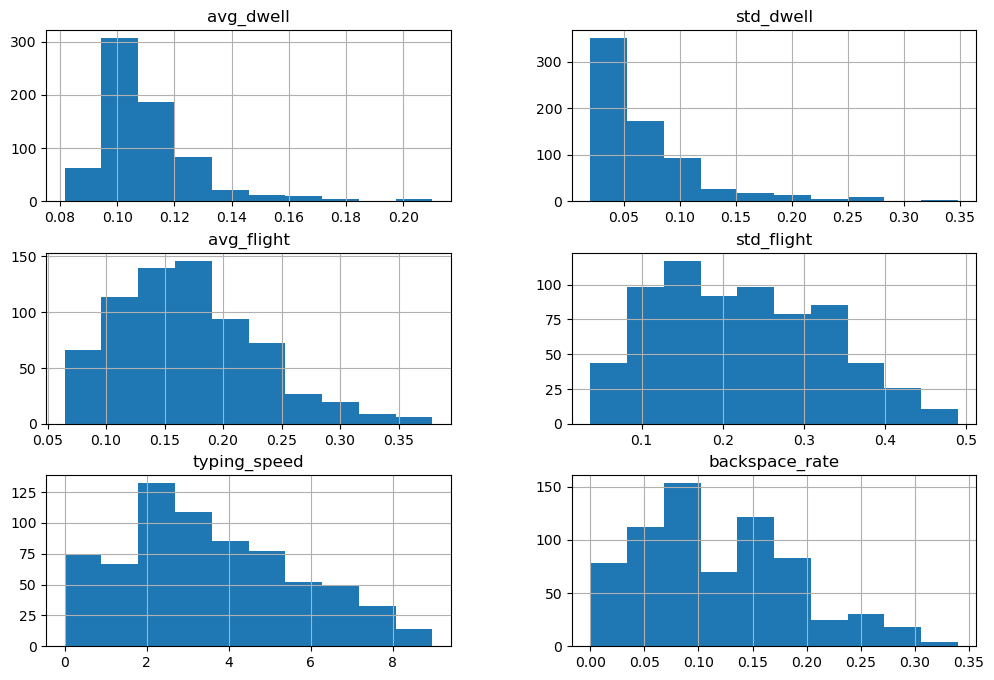

In [ ]:
features_df.hist(figsize=(12, 8)) # plot a histogram showing how many windows fall in the particular bin
# we have 6 features so 6 different histograms

In [ ]:
features_df.to_csv(OUTPUT_FILE, index=False) 
print(f"Saved to {OUTPUT_FILE}")
# finally outputs feature.csv for the next step

Saved to ../features.csv
